# Quiz: Stochastic Process Simulations

This notebook simulates and compares three discrete-time stochastic systems:
1. AWGN filtered by a low-pass system $H(\omega)$
2. AR(3) process
3. ARMA(3, 3) process

Each part includes a short analytical model and an empirical time-domain simulation.

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from numpy.typing import NDArray

plt.style.use("seaborn-v0_8-whitegrid")


def design_fir_lpf(
    sample_rate_hz: float,  # Sampling frequency [Hz]
    cutoff_hz: float,  # Low-pass cutoff frequency [Hz]
    num_taps: int,  # FIR length [samples], must be odd
) -> NDArray[np.float64]:  # FIR impulse response h[n] with unit DC gain
    """Designs a linear-phase FIR LPF approximation to H(w) using windowed-sinc.

    Purpose:
        Build a practical discrete-time LPF for filtering white Gaussian noise.

    Parameters:
        sample_rate_hz: Sampling frequency in Hz.
        cutoff_hz: Desired cutoff frequency in Hz.
        num_taps: Number of FIR coefficients (odd for symmetry).

    Returns:
        Real FIR coefficients h[n], normalized to preserve DC gain.

    Side effects:
        None.
    """
    if sample_rate_hz <= 0.0:
        raise ValueError("sample_rate_hz must be positive.")
    if not (0.0 < cutoff_hz < sample_rate_hz / 2.0):
        raise ValueError("cutoff_hz must be in (0, sample_rate_hz/2).")
    if num_taps < 3 or num_taps % 2 == 0:
        raise ValueError("num_taps must be an odd integer >= 3.")

    # Create a centered index and ideal LPF impulse response.
    n: NDArray[np.float64] = np.arange(num_taps, dtype=np.float64)
    center: float = (num_taps - 1) / 2.0
    normalized_cutoff: float = cutoff_hz / sample_rate_hz
    h_ideal: NDArray[np.float64] = (
        2.0
        * normalized_cutoff
        * np.sinc(2.0 * normalized_cutoff * (n - center))
    )

    # Apply a Hamming window to reduce sidelobes and normalize DC gain.
    h_windowed: NDArray[np.float64] = h_ideal * np.hamming(num_taps)
    h_windowed /= np.sum(h_windowed)
    return h_windowed.astype(np.float64)


def simulate_ar3(
    num_samples: int,  # Number of output samples [samples]
    ar_coeffs: tuple[float, float, float],  # (a1, a2, a3) in AR recursion
    noise_std: float = 1.0,  # Innovation standard deviation
    burn_in_samples: int = 500,  # Discarded warm-up samples [samples]
    random_seed: int = 0,  # Seed for reproducibility
) -> NDArray[np.float64]:  # Simulated AR(3) sequence
    """Simulates a stationary AR(3) process with Gaussian innovations.

    Purpose:
        Generate x[n] = a1 x[n-1] + a2 x[n-2] + a3 x[n-3] + w[n],
        where w[n] is zero-mean white Gaussian noise.

    Parameters:
        num_samples: Final sequence length after burn-in.
        ar_coeffs: AR recursion coefficients (a1, a2, a3).
        noise_std: Standard deviation of w[n].
        burn_in_samples: Warm-up length discarded to reduce transients.
        random_seed: Seed controlling deterministic simulation.

    Returns:
        Length-`num_samples` AR(3) realization.

    Side effects:
        None.
    """
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")
    if noise_std <= 0.0:
        raise ValueError("noise_std must be positive.")
    if burn_in_samples < 0:
        raise ValueError("burn_in_samples must be non-negative.")

    a1, a2, a3 = ar_coeffs
    total_samples: int = num_samples + burn_in_samples

    # Draw innovations and run causal recursion from n=3 onward.
    rng = np.random.default_rng(seed=random_seed)
    innovations: NDArray[np.float64] = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=total_samples,
    ).astype(np.float64)
    x: NDArray[np.float64] = np.zeros(total_samples, dtype=np.float64)

    for n_idx in range(3, total_samples):
        x[n_idx] = (
            a1 * x[n_idx - 1]
            + a2 * x[n_idx - 2]
            + a3 * x[n_idx - 3]
            + innovations[n_idx]
        )

    return x[burn_in_samples:]


def simulate_arma33(
    num_samples: int,  # Number of output samples [samples]
    ar_coeffs: tuple[float, float, float],  # AR coefficients (a1, a2, a3)
    ma_coeffs: tuple[float, float, float],  # MA coefficients (b1, b2, b3)
    noise_std: float = 1.0,  # Innovation standard deviation
    burn_in_samples: int = 500,  # Discarded warm-up samples [samples]
    random_seed: int = 0,  # Seed for reproducibility
) -> NDArray[np.float64]:  # Simulated ARMA(3,3) sequence
    """Simulates an ARMA(3,3) process with Gaussian innovations.

    Purpose:
        Generate x[n] = sum(a_k x[n-k]) + w[n] + sum(b_k w[n-k])
        with k=1..3, combining long-memory AR feedback and short-memory MA shaping.

    Parameters:
        num_samples: Final sequence length after burn-in.
        ar_coeffs: AR recursion coefficients (a1, a2, a3).
        ma_coeffs: MA coefficients (b1, b2, b3).
        noise_std: Standard deviation of w[n].
        burn_in_samples: Warm-up length discarded to reduce transients.
        random_seed: Seed controlling deterministic simulation.

    Returns:
        Length-`num_samples` ARMA(3,3) realization.

    Side effects:
        None.
    """
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")
    if noise_std <= 0.0:
        raise ValueError("noise_std must be positive.")
    if burn_in_samples < 0:
        raise ValueError("burn_in_samples must be non-negative.")

    a1, a2, a3 = ar_coeffs
    b1, b2, b3 = ma_coeffs

    # Keep three extra innovation samples for MA lags at startup.
    total_samples: int = num_samples + burn_in_samples + 3
    rng = np.random.default_rng(seed=random_seed)
    innovations: NDArray[np.float64] = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=total_samples,
    ).astype(np.float64)
    x: NDArray[np.float64] = np.zeros(total_samples, dtype=np.float64)

    for n_idx in range(3, total_samples):
        # AR term models recursive memory from past outputs.
        ar_term: float = (
            a1 * x[n_idx - 1]
            + a2 * x[n_idx - 2]
            + a3 * x[n_idx - 3]
        )
        # MA term shapes current sample using current and delayed innovations.
        ma_term: float = (
            innovations[n_idx]
            + b1 * innovations[n_idx - 1]
            + b2 * innovations[n_idx - 2]
            + b3 * innovations[n_idx - 3]
        )
        x[n_idx] = ar_term + ma_term

    return x[burn_in_samples + 3 :]



def welch_psd_torch(
    signal_samples: NDArray[np.float64],  # Input realization x[n]
    sample_rate_hz: float,  # Sampling frequency [Hz]
    segment_length_samples: int = 512,  # Welch segment length [samples]
    overlap_samples: int | None = None,  # Segment overlap [samples]
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:  # (frequency_hz, PSD)
    """Estimates a one-sided PSD using a Welch method implemented in PyTorch.

    Purpose:
        Provide a deterministic, fully PyTorch-based PSD estimate suitable for
        stochastic-process analysis in this notebook.

    Parameters:
        signal_samples: 1-D discrete-time realization to analyze.
        sample_rate_hz: Sampling frequency in Hz.
        segment_length_samples: Window length used by Welch's method.
        overlap_samples: Overlap between adjacent windows. If ``None``, uses 50% overlap.

    Returns:
        A tuple ``(freq_hz, psd_power_per_hz)`` containing one-sided frequency bins
        and the averaged PSD estimate in power/Hz.

    Side effects:
        None.
    """
    if sample_rate_hz <= 0.0:
        raise ValueError("sample_rate_hz must be positive.")

    x_tensor = torch.as_tensor(signal_samples, dtype=torch.float64)
    if x_tensor.ndim != 1:
        raise ValueError("signal_samples must be one-dimensional.")
    if segment_length_samples <= 0:
        raise ValueError("segment_length_samples must be positive.")
    if x_tensor.numel() < segment_length_samples:
        raise ValueError("segment_length_samples cannot exceed signal length.")

    if overlap_samples is None:
        overlap_samples = segment_length_samples // 2
    if overlap_samples < 0 or overlap_samples >= segment_length_samples:
        raise ValueError(
            "overlap_samples must be in [0, segment_length_samples).",
        )

    # Split x[n] into overlapping segments using stride-based unfolding.
    step_samples: int = segment_length_samples - overlap_samples
    segments = x_tensor.unfold(
        dimension=0,
        size=segment_length_samples,
        step=step_samples,
    )

    # Remove local means and apply a Hann window before FFT.
    segments = segments - torch.mean(segments, dim=1, keepdim=True)
    window = torch.hann_window(
        segment_length_samples,
        periodic=False,
        dtype=torch.float64,
    )
    window_power: torch.Tensor = torch.sum(window**2)
    windowed_segments = segments * window

    # Compute one-sided periodograms and average them (Welch estimate).
    spectrum = torch.fft.rfft(windowed_segments, n=segment_length_samples, dim=1)
    psd_segments = (torch.abs(spectrum) ** 2) / (sample_rate_hz * window_power)

    if segment_length_samples % 2 == 0:
        psd_segments[:, 1:-1] *= 2.0
    else:
        psd_segments[:, 1:] *= 2.0

    psd_mean = torch.mean(psd_segments, dim=0)
    freq_hz = torch.fft.rfftfreq(segment_length_samples, d=1.0 / sample_rate_hz)

    return (
        freq_hz.detach().cpu().numpy().astype(np.float64),
        psd_mean.detach().cpu().numpy().astype(np.float64),
    )



def normalize_process_unit_variance(
    signal_samples: NDArray[np.float64],  # Input realization x[n]
    eps: float = 1e-12,  # Minimum allowed standard deviation
) -> NDArray[np.float64]:  # Zero-mean unit-variance sequence
    """Normalizes a sequence to zero mean and unit variance.

    Purpose:
        Enforce consistent amplitude scaling across time-domain realizations so
        PSD levels can be compared directly.

    Parameters:
        signal_samples: One-dimensional process realization.
        eps: Numerical floor for standard deviation validation.

    Returns:
        Normalized realization with empirical mean approximately zero and
        empirical variance equal to one.

    Side effects:
        None.
    """
    x: NDArray[np.float64] = np.asarray(signal_samples, dtype=np.float64)
    if x.ndim != 1:
        raise ValueError("signal_samples must be one-dimensional.")

    # Remove DC component before setting unit variance.
    x_centered: NDArray[np.float64] = x - float(np.mean(x))
    x_std: float = float(np.std(x_centered, ddof=0))
    if x_std <= eps:
        raise ValueError("signal standard deviation is too small to normalize.")

    return (x_centered / x_std).astype(np.float64)



def prepare_psd_db_for_omega_band(
    freq_hz: NDArray[np.float64],  # One-sided Welch frequency bins [Hz]
    psd_power_per_hz: NDArray[np.float64],  # One-sided PSD estimate [power/Hz]
    omega_max_rad_s: float,  # Maximum plotted angular frequency F [rad/s]
    min_psd_power: float = 1e-18,  # Lower bound before log conversion
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:  # (omega_rad_s, PSD_dB)
    """Converts PSD to normalized dB scale and restricts it to omega in (0, F].

    Purpose:
        Prepare PSD curves for log-frequency plotting with a guaranteed 0 dB
        maximum in the displayed band.

    Parameters:
        freq_hz: One-sided discrete frequency bins from Welch estimation.
        psd_power_per_hz: PSD values associated with ``freq_hz``.
        omega_max_rad_s: Upper angular-frequency limit F for visualization.
        min_psd_power: Lower clipping floor to avoid log(0).

    Returns:
        Tuple ``(omega_rad_s, psd_db)`` where:
        - ``omega_rad_s`` only contains strictly positive values up to F.
        - ``psd_db`` is normalized so its maximum equals exactly 0 dB.

    Side effects:
        None.
    """
    if omega_max_rad_s <= 0.0:
        raise ValueError("omega_max_rad_s must be positive.")

    freq_array_hz: NDArray[np.float64] = np.asarray(freq_hz, dtype=np.float64)
    psd_array: NDArray[np.float64] = np.asarray(psd_power_per_hz, dtype=np.float64)
    if freq_array_hz.ndim != 1 or psd_array.ndim != 1:
        raise ValueError("freq_hz and psd_power_per_hz must be one-dimensional.")
    if freq_array_hz.shape != psd_array.shape:
        raise ValueError("freq_hz and psd_power_per_hz must have the same shape.")

    # Convert to angular frequency and keep only (0, F] for log-omega plotting.
    omega_rad_s: NDArray[np.float64] = 2.0 * np.pi * freq_array_hz
    band_mask: NDArray[np.bool_] = (
        (omega_rad_s > 0.0) & (omega_rad_s <= omega_max_rad_s)
    )
    if not np.any(band_mask):
        raise ValueError("No PSD bins remain inside the requested omega band.")

    omega_band_rad_s: NDArray[np.float64] = omega_rad_s[band_mask]
    psd_band: NDArray[np.float64] = np.maximum(psd_array[band_mask], min_psd_power)

    # Normalize dB level so the displayed maximum is exactly 0 dB.
    psd_band_db: NDArray[np.float64] = 10.0 * np.log10(psd_band)
    psd_band_db -= float(np.max(psd_band_db))

    return (
        omega_band_rad_s.astype(np.float64),
        psd_band_db.astype(np.float64),
    )


## 1) LPF $H(\omega)$ filtering AWGN (analytical)

Let $x[n] \sim \mathcal{N}(0,\sigma_x^2)$ be white Gaussian noise. For an LTI filter with
impulse response $h[n]$ and frequency response $H(e^{j\omega})$:

$$y[n] = (h * x)[n], \qquad S_y(e^{j\omega}) = |H(e^{j\omega})|^2 S_x(e^{j\omega}).$$

Since white noise has flat spectrum $S_x(e^{j\omega}) = \sigma_x^2$, the LPF attenuates
high-frequency power and reduces output variance according to:

$$\sigma_y^2 = \sigma_x^2 \sum_n h^2[n].$$

Below, $H(\omega)$ is implemented numerically as a windowed-sinc FIR LPF.

LPF output variance (theoretical): 0.1528
LPF output variance (empirical):   0.1516
LPF normalized mean:               +9.474e-18
LPF normalized variance:           1.0000


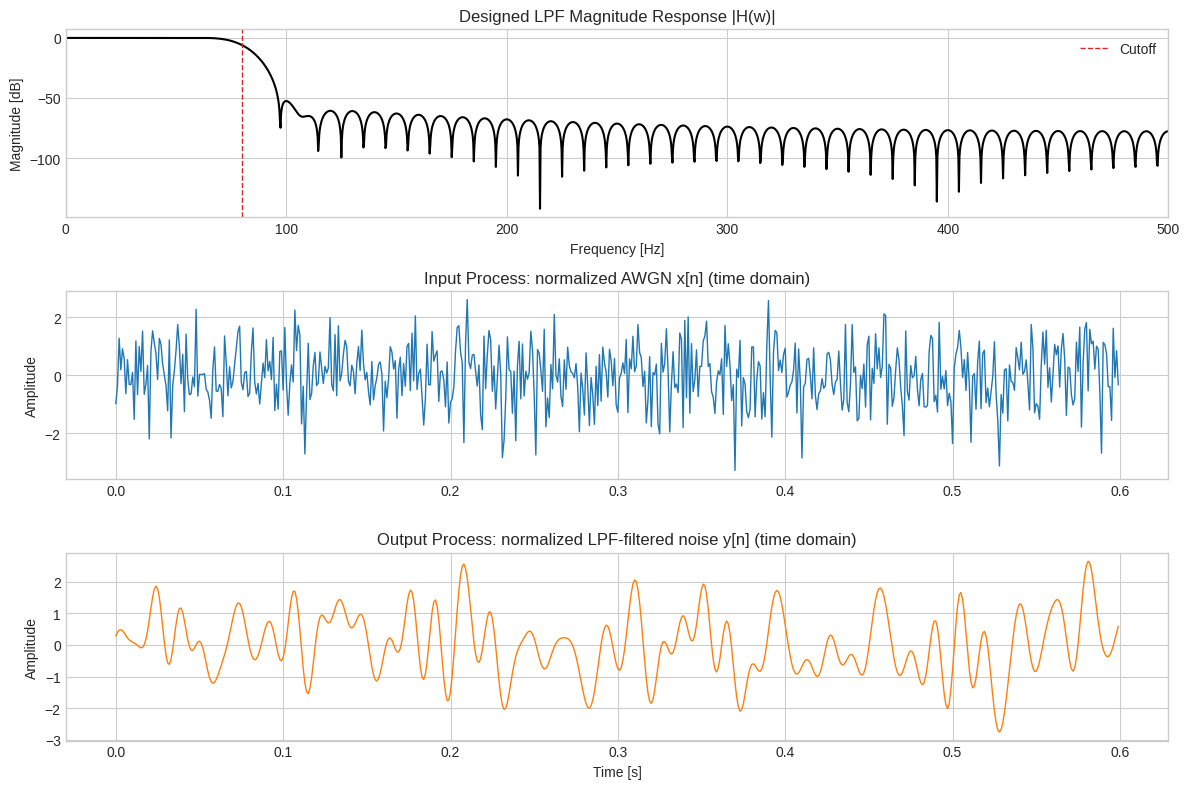

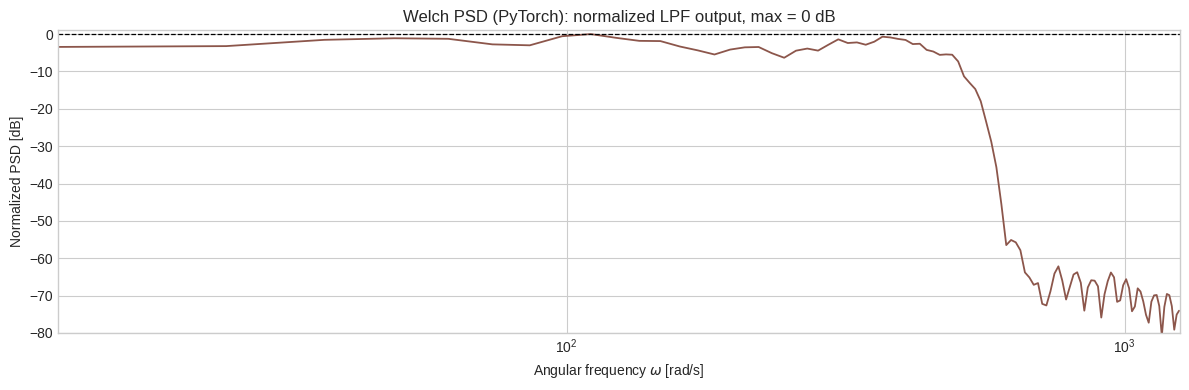

In [10]:
# Simulation parameters with explicit units.
sample_rate_hz: float = 1000.0  # Sampling frequency [Hz]
cutoff_hz: float = 80.0  # LPF cutoff frequency [Hz]
num_taps: int = 101  # FIR length [samples]
num_samples: int = 3000  # Signal length [samples]
noise_std: float = 1.0  # AWGN standard deviation

# Chosen angular-frequency display limit for all PSD figures.
omega_plot_limit_rad_s: float = 2.0 * np.pi * 200.0  # F = 2*pi*200 rad/s

# Generate AWGN input x[n].
rng_lpf = np.random.default_rng(seed=123)
x_awgn: NDArray[np.float64] = rng_lpf.normal(
    loc=0.0,
    scale=noise_std,
    size=num_samples,
).astype(np.float64)

# Build LPF H(w) and filter x[n] to produce y[n].
h_lpf: NDArray[np.float64] = design_fir_lpf(
    sample_rate_hz=sample_rate_hz,
    cutoff_hz=cutoff_hz,
    num_taps=num_taps,
)
y_lpf: NDArray[np.float64] = np.convolve(x_awgn, h_lpf, mode="same")

# Normalize all time-domain sequences used in this section.
x_awgn_norm: NDArray[np.float64] = normalize_process_unit_variance(x_awgn)
y_lpf_norm: NDArray[np.float64] = normalize_process_unit_variance(y_lpf)

# Compare theoretical and empirical output variance before normalization.
sigma_y2_theoretical: float = (noise_std**2) * float(np.sum(h_lpf**2))
sigma_y2_empirical: float = float(np.var(y_lpf, ddof=0))
print(f"LPF output variance (theoretical): {sigma_y2_theoretical:.4f}")
print(f"LPF output variance (empirical):   {sigma_y2_empirical:.4f}")
print(f"LPF normalized mean:               {np.mean(y_lpf_norm):+.3e}")
print(f"LPF normalized variance:           {np.var(y_lpf_norm, ddof=0):.4f}")

# Compute the discrete frequency response to visualize H(w).
fft_size: int = 4096
h_freq = np.fft.rfft(h_lpf, n=fft_size)
freq_hz: NDArray[np.float64] = np.fft.rfftfreq(
    fft_size,
    d=1.0 / sample_rate_hz,
)

# Plot H(w), normalized AWGN input, and normalized LPF output in time domain.
segment_samples: int = 600
time_s: NDArray[np.float64] = np.arange(num_samples, dtype=np.float64) / sample_rate_hz

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
axes[0].plot(freq_hz, 20.0 * np.log10(np.maximum(np.abs(h_freq), 1e-8)), color="black")
axes[0].axvline(cutoff_hz, color="tab:red", linestyle="--", linewidth=1.0, label="Cutoff")
axes[0].set_title("Designed LPF Magnitude Response |H(w)|")
axes[0].set_ylabel("Magnitude [dB]")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_xlim(0.0, sample_rate_hz / 2.0)
axes[0].legend()

axes[1].plot(
    time_s[:segment_samples],
    x_awgn_norm[:segment_samples],
    color="tab:blue",
    linewidth=1.0,
)
axes[1].set_title("Input Process: normalized AWGN x[n] (time domain)")
axes[1].set_ylabel("Amplitude")

axes[2].plot(
    time_s[:segment_samples],
    y_lpf_norm[:segment_samples],
    color="tab:orange",
    linewidth=1.0,
)
axes[2].set_title("Output Process: normalized LPF-filtered noise y[n] (time domain)")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

# Estimate and plot PSD of normalized LPF-filtered process using torch-based Welch.
welch_segment_lpf_samples: int = 512
welch_overlap_lpf_samples: int = 256
freq_lpf_psd_hz, psd_lpf_power_per_hz = welch_psd_torch(
    signal_samples=y_lpf_norm,
    sample_rate_hz=sample_rate_hz,
    segment_length_samples=welch_segment_lpf_samples,
    overlap_samples=welch_overlap_lpf_samples,
)
omega_lpf_rad_s, psd_lpf_db = prepare_psd_db_for_omega_band(
    freq_hz=freq_lpf_psd_hz,
    psd_power_per_hz=psd_lpf_power_per_hz,
    omega_max_rad_s=omega_plot_limit_rad_s,
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(omega_lpf_rad_s, psd_lpf_db, color="tab:brown", linewidth=1.3)
ax.set_xscale("log")
ax.axhline(0.0, color="black", linestyle="--", linewidth=0.9)
ax.set_title("Welch PSD (PyTorch): normalized LPF output, max = 0 dB")
ax.set_xlabel(r"Angular frequency $\omega$ [rad/s]")
ax.set_ylabel("Normalized PSD [dB]")
ax.set_xlim(float(np.min(omega_lpf_rad_s)), omega_plot_limit_rad_s)
ax.set_ylim(-80.0, 1.0)
plt.tight_layout()
plt.show()


## 2) AR(3) process (analytical)

The AR(3) model is:

$$x[n] = a_1 x[n-1] + a_2 x[n-2] + a_3 x[n-3] + w[n], \quad w[n] \sim \mathcal{N}(0, \sigma_w^2).$$

With $A(z) = 1 - a_1 z^{-1} - a_2 z^{-2} - a_3 z^{-3}$, the transfer function from
innovation to output is $H(z) = 1/A(z)$. A stable AR part yields a stationary process.

Here we use poles $p = \{0.75, -0.45, 0.25\}$ in the recursion design, which gives:

$$a_1 = 0.55, \quad a_2 = 0.2625, \quad a_3 = -0.084375.$$

AR(3) normalized mean: +1.184e-17
AR(3) normalized var:  1.0000


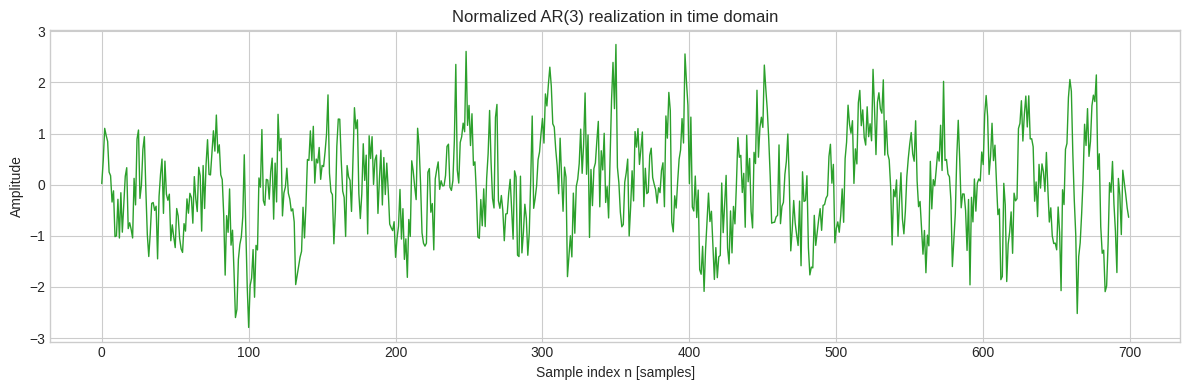

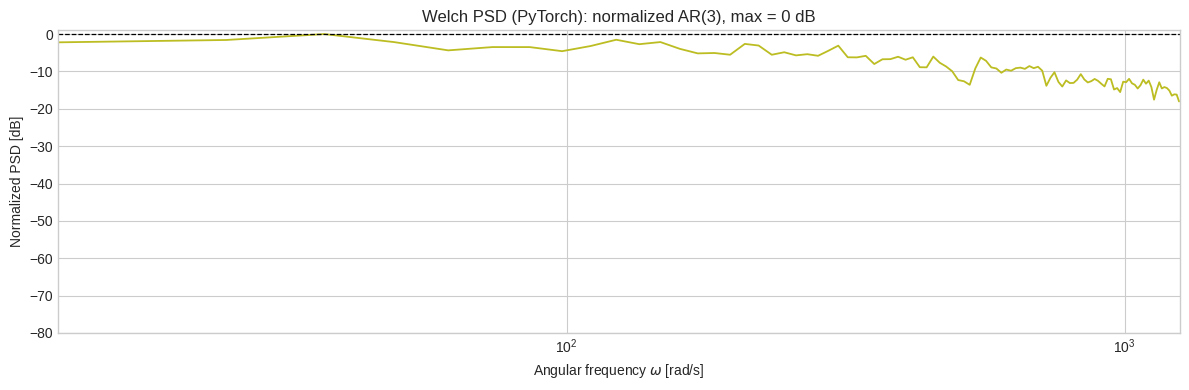

In [11]:
num_samples_ar3: int = 3000  # Output length [samples]
noise_std_ar3: float = 1.0  # Innovation standard deviation
ar3_coeffs: tuple[float, float, float] = (0.55, 0.2625, -0.084375)

x_ar3: NDArray[np.float64] = simulate_ar3(
    num_samples=num_samples_ar3,
    ar_coeffs=ar3_coeffs,
    noise_std=noise_std_ar3,
    burn_in_samples=600,
    random_seed=321,
)

# Normalize the AR(3) realization for consistent time-domain and PSD scaling.
x_ar3_norm: NDArray[np.float64] = normalize_process_unit_variance(x_ar3)

print(f"AR(3) normalized mean: {np.mean(x_ar3_norm):+.3e}")
print(f"AR(3) normalized var:  {np.var(x_ar3_norm, ddof=0):.4f}")

segment_samples_ar3: int = 700
n_ar3: NDArray[np.int64] = np.arange(num_samples_ar3, dtype=np.int64)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    n_ar3[:segment_samples_ar3],
    x_ar3_norm[:segment_samples_ar3],
    color="tab:green",
    linewidth=1.0,
)
ax.set_title("Normalized AR(3) realization in time domain")
ax.set_xlabel("Sample index n [samples]")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Estimate and plot PSD of normalized AR(3) realization using torch-based Welch.
welch_segment_ar3_samples: int = 512
welch_overlap_ar3_samples: int = 256
freq_ar3_psd_hz, psd_ar3_power_per_hz = welch_psd_torch(
    signal_samples=x_ar3_norm,
    sample_rate_hz=sample_rate_hz,
    segment_length_samples=welch_segment_ar3_samples,
    overlap_samples=welch_overlap_ar3_samples,
)
omega_ar3_rad_s, psd_ar3_db = prepare_psd_db_for_omega_band(
    freq_hz=freq_ar3_psd_hz,
    psd_power_per_hz=psd_ar3_power_per_hz,
    omega_max_rad_s=omega_plot_limit_rad_s,
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(omega_ar3_rad_s, psd_ar3_db, color="tab:olive", linewidth=1.3)
ax.set_xscale("log")
ax.axhline(0.0, color="black", linestyle="--", linewidth=0.9)
ax.set_title("Welch PSD (PyTorch): normalized AR(3), max = 0 dB")
ax.set_xlabel(r"Angular frequency $\omega$ [rad/s]")
ax.set_ylabel("Normalized PSD [dB]")
ax.set_xlim(float(np.min(omega_ar3_rad_s)), omega_plot_limit_rad_s)
ax.set_ylim(-80.0, 1.0)
plt.tight_layout()
plt.show()


## 3) ARMA(3, 3) process (analytical)

The ARMA(3,3) model is:

$$x[n] = \sum_{k=1}^{3} a_k x[n-k] + w[n] + \sum_{k=1}^{3} b_k w[n-k],$$

with white innovation $w[n]$. The transfer function is:

$$H(z) = \frac{B(z)}{A(z)} = \frac{1 + b_1 z^{-1} + b_2 z^{-2} + b_3 z^{-3}}{1 - a_1 z^{-1} - a_2 z^{-2} - a_3 z^{-3}}.$$

Compared with pure AR, the MA part adds short-memory shaping of innovations,
while the AR part controls recursive structure.

We reuse the same AR coefficients and choose MA coefficients:

$$b_1 = 0.65, \quad b_2 = -0.35, \quad b_3 = 0.15.$$

ARMA(3,3) normalized mean: -4.737e-18
ARMA(3,3) normalized var:  1.0000


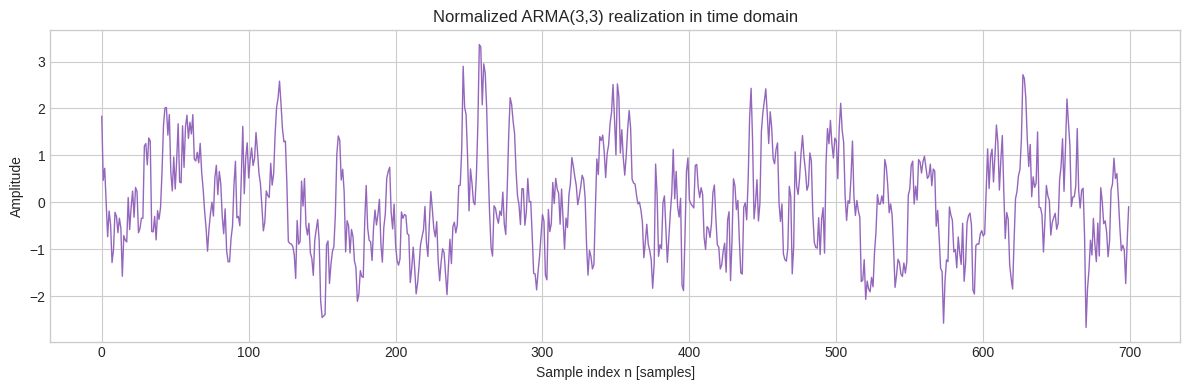

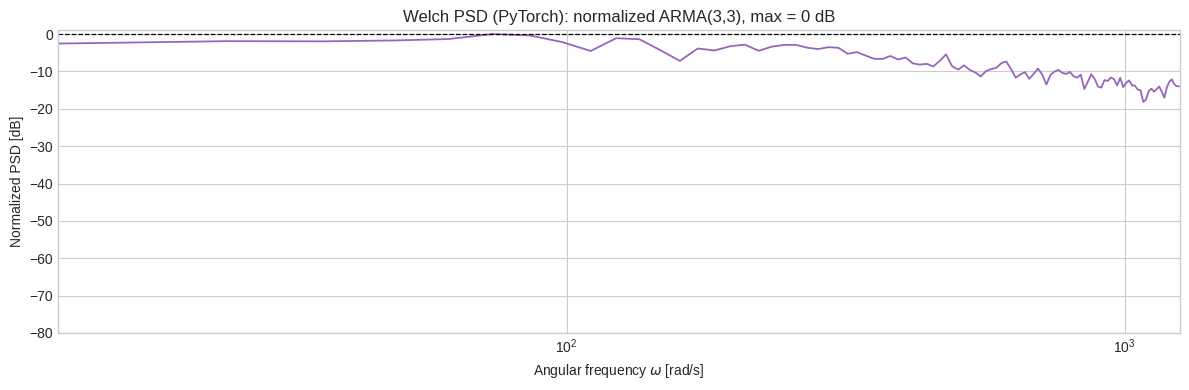

In [12]:
num_samples_arma33: int = 3000  # Output length [samples]
noise_std_arma33: float = 1.0  # Innovation standard deviation
ar_coeffs_arma33: tuple[float, float, float] = (0.55, 0.2625, -0.084375)
ma_coeffs_arma33: tuple[float, float, float] = (0.65, -0.35, 0.15)

x_arma33: NDArray[np.float64] = simulate_arma33(
    num_samples=num_samples_arma33,
    ar_coeffs=ar_coeffs_arma33,
    ma_coeffs=ma_coeffs_arma33,
    noise_std=noise_std_arma33,
    burn_in_samples=600,
    random_seed=999,
)

# Normalize the ARMA(3,3) realization for consistent time-domain and PSD scaling.
x_arma33_norm: NDArray[np.float64] = normalize_process_unit_variance(x_arma33)

print(f"ARMA(3,3) normalized mean: {np.mean(x_arma33_norm):+.3e}")
print(f"ARMA(3,3) normalized var:  {np.var(x_arma33_norm, ddof=0):.4f}")

segment_samples_arma: int = 700
n_arma: NDArray[np.int64] = np.arange(num_samples_arma33, dtype=np.int64)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    n_arma[:segment_samples_arma],
    x_arma33_norm[:segment_samples_arma],
    color="tab:purple",
    linewidth=1.0,
)
ax.set_title("Normalized ARMA(3,3) realization in time domain")
ax.set_xlabel("Sample index n [samples]")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Estimate and plot PSD of normalized ARMA(3,3) realization using torch-based Welch.
welch_segment_arma33_samples: int = 512
welch_overlap_arma33_samples: int = 256
freq_arma33_psd_hz, psd_arma33_power_per_hz = welch_psd_torch(
    signal_samples=x_arma33_norm,
    sample_rate_hz=sample_rate_hz,
    segment_length_samples=welch_segment_arma33_samples,
    overlap_samples=welch_overlap_arma33_samples,
)
omega_arma33_rad_s, psd_arma33_db = prepare_psd_db_for_omega_band(
    freq_hz=freq_arma33_psd_hz,
    psd_power_per_hz=psd_arma33_power_per_hz,
    omega_max_rad_s=omega_plot_limit_rad_s,
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    omega_arma33_rad_s,
    psd_arma33_db,
    color="tab:purple",
    linewidth=1.3,
)
ax.set_xscale("log")
ax.axhline(0.0, color="black", linestyle="--", linewidth=0.9)
ax.set_title("Welch PSD (PyTorch): normalized ARMA(3,3), max = 0 dB")
ax.set_xlabel(r"Angular frequency $\omega$ [rad/s]")
ax.set_ylabel("Normalized PSD [dB]")
ax.set_xlim(float(np.min(omega_arma33_rad_s)), omega_plot_limit_rad_s)
ax.set_ylim(-80.0, 1.0)
plt.tight_layout()
plt.show()
